# 🧠 HUẤN LUYỆN MẠNG NƠ-RON TÍCH CHẬP (CNN) NHẬN DIỆN U NÃO VÀ GRAD-CAM
**Nhóm 9 - Học Máy 2026**

Notebook này thực hiện huấn luyện mô hình học sâu **CNN** bằng thư viện **PyTorch** để phân loại u não qua ảnh MRI, kết hợp các thuật toán tiền xử lý ảnh của **OpenCV** và giải thích mô hình bằng bản đồ nhiệt **Grad-CAM**.

### 1. Khai báo thư viện và Module tiện ích

In [6]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Nhập các tiện ích tự xây dựng từ utils.py
from utils import (
    BrainTumorCNN, BrainTumorCNN_V2, BrainTumorCNN_V3,
    GradCAM,
    preprocess_image_for_model,
    # setup_synthetic_dataset
)

# Thiết lập hạt giống ngẫu nhiên để tái lặp kết quả
torch.manual_seed(42)
np.random.seed(42)

### 2. Thiết lập dữ liệu (Chế độ tự động sinh ảnh giả lập nếu chưa có dữ liệu thực)

In [2]:
# Tự động sinh dữ liệu MRI giả lập (hoặc phát hiện dataset thực tế nếu có sẵn trong thư mục 'dataset')
# setup_synthetic_dataset(base_dir="dataset", num_train_per_class=40, num_test_per_class=10)

### 3. Xây dựng Class Dataset PyTorch để Load ảnh

In [3]:
class BrainTumorDataset(Dataset):
    def __init__(self, base_dir, split="train"):
        # Tự động hỗ trợ cả thư mục 'Training' và 'Testing' của người dùng giải nén
        if False: # Đã tắt hardcode
            pass
        else:
            self.split_dir = os.path.join(base_dir, split)
        self.classes = ["glioma", "meningioma", "notumor", "pituitary"]
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        
        self.image_paths = []
        self.labels = []
        self.split = split
        self.aug = T.Compose([T.RandomHorizontalFlip(p=0.5), T.RandomRotation(15), T.RandomAffine(degrees=0, translate=(0.1, 0.1))]) if split.lower() == "train" else None
        
        for c in self.classes:
            class_path = os.path.join(self.split_dir, c)
            if not os.path.exists(class_path): 
                continue
            for filename in os.listdir(class_path):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(class_path, filename))
                    self.labels.append(self.class_to_idx[c])
                    
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Đọc ảnh gốc bằng OpenCV
        img = cv2.imread(img_path)
        
        # Thực hiện Tiền xử lý OpenCV (Cắt sọ -> Resize -> Chuẩn hóa) ở utils.py
        _, _, tensor_img = preprocess_image_for_model(img)
        
        # tensor_img ban đầu có shape (1, 3, 224, 224), ta bỏ chiều batch đi để DataLoader gom cụm
        tensor_img = tensor_img.squeeze(0)
        if self.aug:
            tensor_img = self.aug(tensor_img)
        return tensor_img, label
        
        return tensor_img, label

# Khởi tạo dataset train/test
train_dataset = BrainTumorDataset("Kaggle_Dataset", split="Train")
test_dataset = BrainTumorDataset("Kaggle_Dataset", split="Test")

# Khởi tạo DataLoader để cung cấp dữ liệu theo cụm (Batch size = 8)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Số lượng ảnh tập Test: {len(test_dataset)}")

Số lượng ảnh tập Train: 5600
Số lượng ảnh tập Test: 1600


### 4. Khởi tạo mô hình CNN, Hàm mất mát và Thuật toán tối ưu

In [4]:
# Khởi chạy trên CPU (do chạy cục bộ)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang chạy trên thiết bị: {device}")

import torchvision.models as models
# Khởi tạo mô hình ResNet18 pre-trained trên ImageNet
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Sửa lớp Fully Connected cuối cùng từ 1000 class (ImageNet) thành 4 class (U não)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
model = model.to(device)

# Hàm lỗi Cross Entropy Loss (Dành cho phân loại đa lớp)
criterion = nn.CrossEntropyLoss()

# Thuật toán tối ưu Adam (Ưu việt hơn Gradient Descent cơ bản)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Thêm ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2)

Đang chạy trên thiết bị: cuda


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


### 5. Huấn luyện mô hình (Training Loop)

In [5]:

# ==========================================
# CẤU HÌNH HUẤN LUYỆN
# ==========================================
epochs = 50
patience = 7 # Số epoch kiên nhẫn cho Early Stopping
train_losses, train_accs = [], []
val_losses, val_accs = [] , []
best_val_loss = float('inf')
epochs_no_improve = 0
print(f"Bắt đầu huấn luyện mô hình (Dự kiến {epochs} epochs)...")
for epoch in range(epochs):
    # -------------------------
    # 1. PHA HUẤN LUYỆN (TRAINING)
    # -------------------------
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
        
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    
    # -------------------------
    # 2. PHA ĐÁNH GIÁ (VALIDATION)
    # -------------------------
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, targets in test_loader: # Dùng tập test làm validation
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += targets.size(0)
            val_correct += (predicted == targets).sum().item()
            
    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc*100:.2f}% | Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc*100:.2f}%")
    
    # Cập nhật Scheduler dựa trên val_loss
    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"  => Tốc độ học hiện tại: {current_lr:.6f}")
    
    # -------------------------
    # 3. EARLY STOPPING & CHECKPOINTING
    # -------------------------
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model_resnet18.pth")
        print(f"  => Validation Loss giảm, đã lưu mô hình tốt nhất!")
    else:
        epochs_no_improve += 1
        print(f"  => Validation Loss không cải thiện ({epochs_no_improve}/{patience})")
        
    if epochs_no_improve >= patience:
        print(f"\n🚀 Đã kích hoạt Early Stopping tại epoch {epoch+1}!")
        break
# Xuất lịch sử huấn luyện ra file JSON
history = {
    "train_losses": train_losses, "train_accs": train_accs,
    "val_losses": val_losses, "val_accs": val_accs
}
with open("history_resnet18.json", "w") as f:
    json.dump(history, f)
print("\nĐã hoàn tất quá trình huấn luyện và lưu lịch sử!")

Bắt đầu huấn luyện mô hình (Dự kiến 50 epochs)...
Epoch [1/50] | Train Loss: 0.6179 - Acc: 77.41% | Val Loss: 0.6417 - Acc: 81.25%
  => Tốc độ học hiện tại: 0.001000
  => Validation Loss giảm, đã lưu mô hình tốt nhất!
Epoch [2/50] | Train Loss: 0.4309 - Acc: 84.82% | Val Loss: 1.1713 - Acc: 62.38%
  => Tốc độ học hiện tại: 0.001000
  => Validation Loss không cải thiện (1/7)
Epoch [3/50] | Train Loss: 0.3359 - Acc: 88.32% | Val Loss: 0.4356 - Acc: 87.38%
  => Tốc độ học hiện tại: 0.001000
  => Validation Loss giảm, đã lưu mô hình tốt nhất!
Epoch [4/50] | Train Loss: 0.2849 - Acc: 90.30% | Val Loss: 0.4440 - Acc: 86.81%
  => Tốc độ học hiện tại: 0.001000
  => Validation Loss không cải thiện (1/7)
Epoch [5/50] | Train Loss: 0.2778 - Acc: 90.21% | Val Loss: 0.6122 - Acc: 82.00%
  => Tốc độ học hiện tại: 0.001000
  => Validation Loss không cải thiện (2/7)
Epoch [6/50] | Train Loss: 0.2374 - Acc: 92.16% | Val Loss: 0.3721 - Acc: 88.94%
  => Tốc độ học hiện tại: 0.001000
  => Validation Loss 

### 6. Đánh giá mô hình trên tập Test (Evaluation Metrics)

In [7]:
# Tải lại trọng số tốt nhất (nếu có) trước khi đánh giá chi tiết
if os.path.exists("best_model_resnet18.pth"):
    model.load_state_dict(torch.load("best_model_resnet18.pth"))
    print("✅ Đã tải mô hình tốt nhất từ 'best_model_resnet18.pth' để đánh giá.\n")

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

classes = ["glioma", "meningioma", "notumor", "pituitary"]

# 1. In báo cáo các chỉ số Accuracy, Precision, Recall, F1-Score
print("=== BÁO CÁO HIỆU NĂNG MÔ HÌNH (SKLEARN) ===")
print(classification_report(all_targets, all_preds, target_names=classes))

# 2. Vẽ ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix - Nhận diện U Não")
plt.xlabel("Dự đoán của AI")
plt.ylabel("Thực tế bệnh nhân")
plt.show()

NameError: name 'model' is not defined

### 7. Trực quan hóa đường cong học tập (Loss và Accuracy)

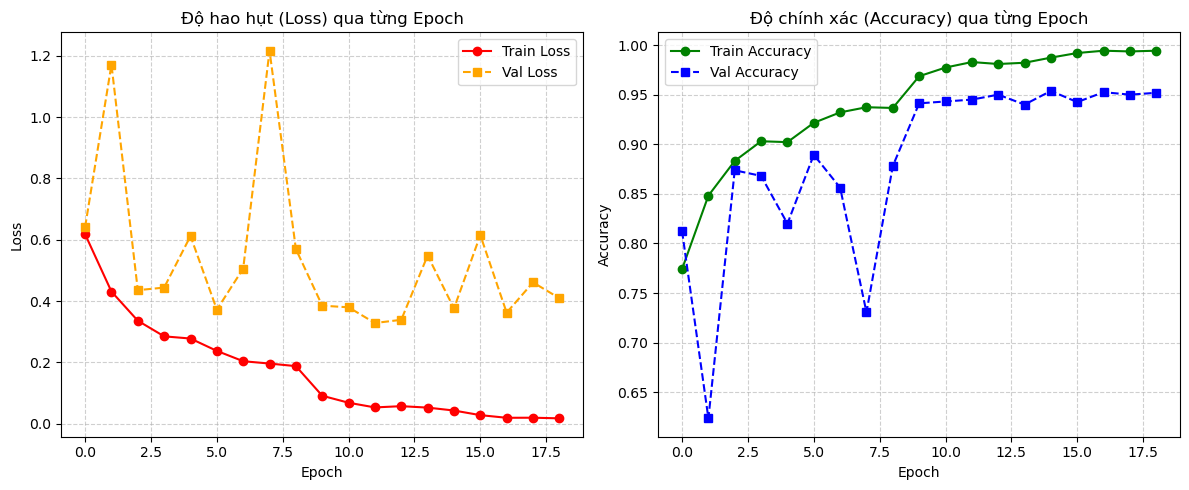

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", color='red', marker='o')
plt.plot(val_losses, label="Val Loss", color='orange', marker='s', linestyle='--')
plt.title("Độ hao hụt (Loss) qua từng Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy", color='green', marker='o')
plt.plot(val_accs, label="Val Accuracy", color='blue', marker='s', linestyle='--')
plt.title("Độ chính xác (Accuracy) qua từng Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 8. Thử nghiệm thuật toán giải thích Grad-CAM trên ảnh mẫu

✅ Đã tải thành công trọng số mô hình từ lần Train trước!
🔍 Sinh bản đồ nhiệt cho nhãn: meningioma...


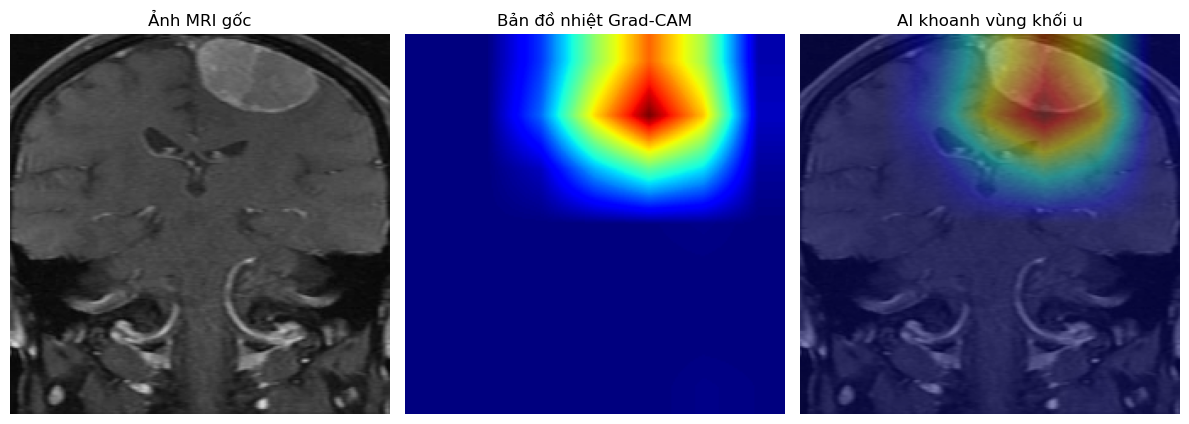

In [29]:
import os
import cv2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.models as models
from utils import GradCAM, preprocess_image_for_model
# 1. Khởi tạo device và tạo khung mô hình ResNet18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=None) # weights=None vì mình sẽ nạp file tự train
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
model = model.to(device)
# 2. Bỏ qua bước Train, Nạp trực tiếp trọng số đã lưu từ ổ cứng
model_path = "best_model_resnet18.pth"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    print("✅ Đã tải thành công trọng số mô hình từ lần Train trước!")
else:
    print("❌ CẢNH BÁO: Không tìm thấy file best_model_resnet18.pth. Phải chăng bạn chưa train xong?")
# 3. Hàm tạo bản đồ nhiệt
def explain_tumor_image(image_path, target_model, class_idx=None):
    orig_img = cv2.imread(image_path)
    if orig_img is None:
        print(f"❌ Không tìm thấy ảnh tại: {image_path}")
        return
        
    cropped, resized, tensor_img = preprocess_image_for_model(orig_img)
    tensor_img = tensor_img.to(device)
    classes = ["glioma", "meningioma", "notumor", "pituitary"]
    if class_idx is None:
        target_model.eval()
        with torch.no_grad():
            outputs = target_model(tensor_img)
            class_idx = torch.argmax(outputs, dim=1).item()
            
    print(f"🔍 Sinh bản đồ nhiệt cho nhãn: {classes[class_idx]}...")
    # Chỉnh đúng target_layer cho ResNet18
    grad_cam = GradCAM(model=target_model, target_layer=target_model.layer4[-1].conv2)
    heatmap = grad_cam.generate_heatmap(tensor_img, class_idx=class_idx)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(resized, 0.6, heatmap_color, 0.4, 0)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
    plt.title("Ảnh MRI gốc")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Bản đồ nhiệt Grad-CAM")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title("AI khoanh vùng khối u")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
# 4. Thay đường dẫn và chạy luôn (Bạn nhớ thêm chữ 'r' để tránh lỗi đường dẫn)
# duong_dan_anh = "D:\Brain_Tumor_Project\Kaggle_Dataset\Test\glioma\Te-gl_53.jpg"
# duong_dan_anh = "D:\Brain_Tumor_Project\Kaggle_Dataset\Test\pituitary\Te-pi_37.jpg"
duong_dan_anh = r"D:\Brain_Tumor_Project\Kaggle_Dataset\Test\meningioma\Te-me_1.jpg"
explain_tumor_image(duong_dan_anh, model)

### 9. Lưu trọng số mô hình tốt nhất

In [10]:
model_save_path = "brain_tumor_resnet18.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Đã lưu thành công trọng số mô hình tại tệp '{model_save_path}'!")

Đã lưu thành công trọng số mô hình tại tệp 'brain_tumor_resnet18.pth'!
